<>:23: SyntaxWarning: invalid escape sequence '\d'
<>:44: SyntaxWarning: invalid escape sequence '\d'
<>:23: SyntaxWarning: invalid escape sequence '\d'
<>:44: SyntaxWarning: invalid escape sequence '\d'
C:\Users\dkoch\AppData\Local\Temp\ipykernel_19384\2616867070.py:23: SyntaxWarning: invalid escape sequence '\d'
  plt.ylabel('$\dot{x}$')
C:\Users\dkoch\AppData\Local\Temp\ipykernel_19384\2616867070.py:44: SyntaxWarning: invalid escape sequence '\d'
  plt.ylabel('$\dot{x}$')


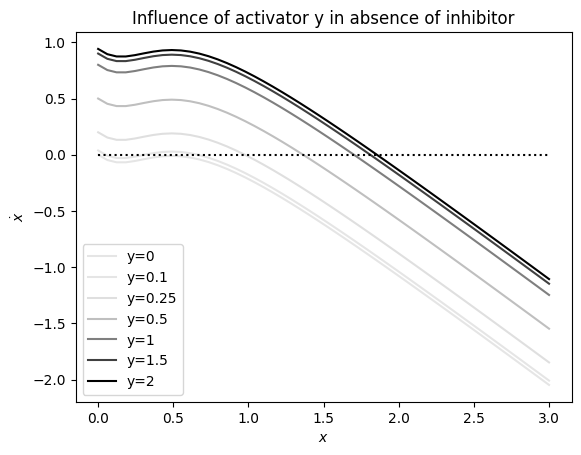

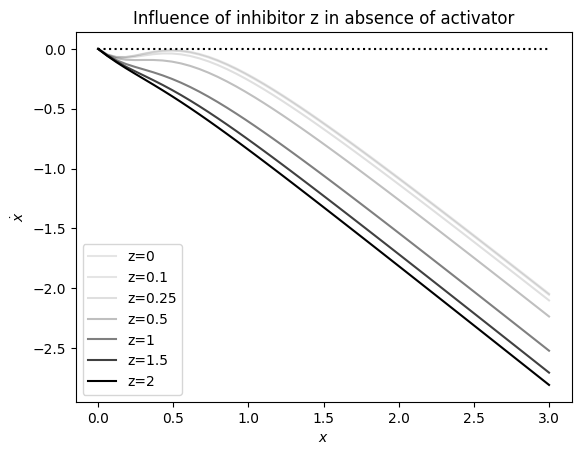

In [1]:
import numpy as np 
import matplotlib.pyplot as plt

x = np.linspace(0,3)

a = 0.98
b=1
K = 0.5
Kr= 1
z = 0
h = 2


plt.plot(x,0*x,':k')

for y in [0, 0.1,0.25,0.5,1,1.5,2]:

    f = lambda x: (a*x**2/(x**2+K**2)+b*y**2/(y**2+K**2))*(Kr**2/(z**2+Kr**2))-x
    plt.plot(x,f(x),'-k',alpha=max(y/2,0.1),label='y='+str(y))

plt.title("Influence of activator y in absence of inhibitor")
plt.xlabel('$x$')
plt.ylabel('$\dot{x}$')
plt.legend()
plt.show()

a = 0.98
b=1
K = 0.5
Kr= 1
y = 0
h = 2


plt.plot(x,0*x,':k')

for z in [0, 0.1,0.25,0.5,1,1.5,2]:

    f = lambda x: (a*x**2/(x**2+K**2)+b*y**2/(y**2+K**2))*(Kr**2/(z**2+Kr**2))-x
    plt.plot(x,f(x),'-k',alpha=max(z/2,0.1),label='z='+str(z))

plt.title("Influence of inhibitor z in absence of activator")
plt.xlabel('$x$')
plt.ylabel('$\dot{x}$')
plt.legend()
plt.show()


In [ ]:

K = 0.5

f = lambda x: a*x**2/(x**2+K**2)-x

C:\Users\dkoch\AppData\Local\Temp\ipykernel_15564\1450235311.py:16: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  r = fsolve(f, guess)[0]
C:\Users\dkoch\AppData\Local\Temp\ipykernel_15564\1450235311.py:16: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  r = fsolve(f, guess)[0]


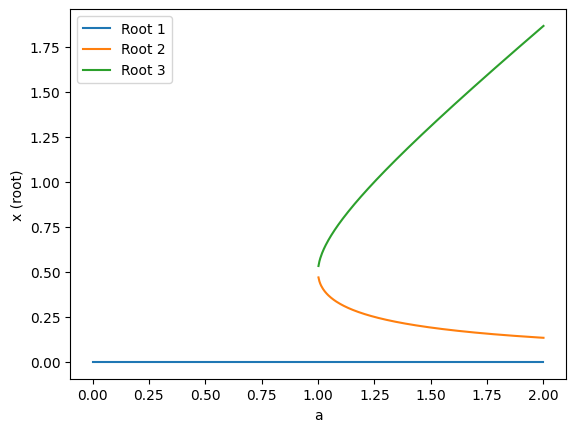

In [7]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

K = 0.5
a_values = np.linspace(0, 2, 500)
roots_list = []

for a in a_values:
    def f(x):
        return a * x**2 / (x**2 + K**2) - x
    
    roots = []
    for guess in [0, 0.1, 0.25, 0.5, 1]:
        try:
            r = fsolve(f, guess)[0]
            if abs(f(r)) < 1e-6:
                roots.append(r)
        except:
            pass
    roots = sorted(set([round(r, 6) for r in roots]))  # unique and rounded
    roots_list.append(roots)

# Plot
plt.figure()
for i in range(max(len(r) for r in roots_list)):
    x_vals = [r[i] if i < len(r) else np.nan for r in roots_list]
    plt.plot(a_values, x_vals, label=f'Root {i+1}')
plt.xlabel('a')
plt.ylabel('x (root)')
plt.legend()
plt.show()

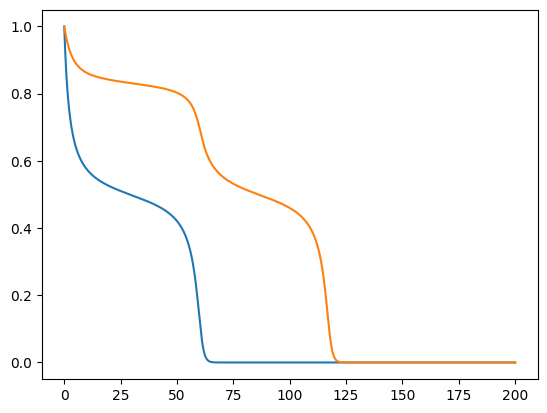

In [31]:
from scipy.integrate import solve_ivp

def grn2g(t, z, para): 
    a,b,K = para
    g1_dot = a*z[0]**2/(z[0]**2+K**2)-z[0]
    g2_dot = (a*z[1]**2/(z[1]**2+K**2)+b*z[0]**2/(z[0]**2+K**2))-z[1]
    return np.array([g1_dot,g2_dot])

para = [0.995,0.2,0.5]
dt = 0.01
t_end=200
timesteps = np.linspace(0,t_end,int(t_end/dt))
sol = solve_ivp(grn2g, (0, t_end), [1,1],
                    t_eval=timesteps, args=(para,),method='RK45',rtol=1e-4,atol=1e-6)

plt.plot(sol.t,sol.y[0])
plt.plot(sol.t,sol.y[1])

In [121]:
import networkx as nx
from matplotlib.patches import FancyArrowPatch
from networkx.drawing.nx_agraph import graphviz_layout

def draw_custom_edges(G, pos, edgelist, color="red", head_length=10, head_width=5, width=1, rad=0.1, trim_fraction=0.1):
    """
    Draws edges using FancyArrowPatch. Instead of drawing an arrow from the exact start to end points,
    the arrow is drawn only along the inner portion of the edge. The arrow starts at:
      (x1, y1) + trim_fraction * (x2 - x1, y2 - y1)
    and ends at:
      (x1, y1) + (1 - trim_fraction) * (x2 - x1, y2 - y1)
    
    mutation_scale is set to 1.
    """
    ax = plt.gca()  # Get current axis
    for u, v in edgelist:
        if u in pos and v in pos:
            x1, y1 = pos[u]
            x2, y2 = pos[v]
            tf = trim_fraction
            # Compute trimmed start and end points
            l = tf * np.sqrt((y2-y1)**2+(x2-x1)**2)
            if l > 30000: 
                tf = 28000/np.sqrt((y2-y1)**2+(x2-x1)**2)
                
            # if l < 10000: 
            #     tf = 10000/np.sqrt((y2-y1)**2+(x2-x1)**2)
            start = (x1 + tf * (x2 - x1), y1 + tf * (y2 - y1))
            end = (x1 + (1 - tf) * (x2 - x1), y1 + (1 - tf) * (y2 - y1))
            
            arrow = FancyArrowPatch(
                start, end,
                arrowstyle=f"-|>,head_length={head_length},head_width={head_width}",
                color=color,
                linewidth=width,
                connectionstyle=f"arc3,rad={rad}",
                mutation_scale=1  # Set mutation_scale as requested
            )
            ax.add_patch(arrow)

def draw_network(
    adj_matrix,
    nodeColMap,
    nlbls,
    layout="fdp",
    graphviz_args=None,
    layout_kwargs=None,
    rankdir="TB",
    node_size=1800,           
    label_font_size=16.5,     
    font="Arial"
):
    """
    layout options
    --------------
    Graphviz:
        'fdp', 'dot', 'neato', 'sfdp', 'circo'
    Semantic aliases:
        'hierarchical' -> Graphviz 'dot'
    NetworkX:
        any nx.*_layout function (NOT nx.draw_*)
    """

    if layout_kwargs is None:
        layout_kwargs = {}

    nw_dim = adj_matrix.shape[0]
    G = nx.from_numpy_array(adj_matrix.transpose(), create_using=nx.DiGraph)

    # --- Define edges ------------------------------------------------------
    inhEdges, actEdges = [], []
    for i in range(nw_dim):
        for ii in range(nw_dim):
            if adj_matrix[i, ii] == 1:
                G.add_edge(i, ii, weight=1)
                actEdges.append((i, ii))
            elif adj_matrix[i, ii] == -1:
                G.add_edge(i, ii, weight=-1)
                inhEdges.append((i, ii))

    # --- Layout handling ---------------------------------------------------
    if graphviz_args is None:
        graphviz_args = (
            f"-Grankdir={rankdir} "
            "-Nwidth=350 -Nheight=350 -Nfixedsize=true "
            "-Goverlap=scale -Gnodesep=5000 -Granksep=200 "
            "-Nshape=oval -Nfontsize=14 -Econstraint=true"
        )

    if layout == "hierarchical":
        layout = "dot"

    if isinstance(layout, str):
        pos = graphviz_layout(G, prog=layout, args=graphviz_args)

    elif callable(layout):
        if layout.__name__.startswith("draw_"):
            raise ValueError(
                f"{layout.__name__} is a drawing function. "
                "Use a layout function like nx.spectral_layout instead."
            )
        pos = layout(G, **layout_kwargs)

    else:
        raise ValueError("layout must be a string or a callable")

    # --- Draw nodes --------------------------------------------------------
    node_opts = {
        "node_size": node_size,
        "edgecolors": "white",
    }
    nx.draw_networkx_nodes(
        G, pos, node_color=nodeColMap, **node_opts, alpha=0.90
    )

    # --- Draw edges --------------------------------------------------------
    draw_custom_edges(
        G, pos, actEdges,
        color="k", head_length=8, head_width=4,
        width=1.1, trim_fraction=0.2
    )
    draw_custom_edges(
        G, pos, inhEdges,
        color="red", head_length=8, head_width=4,
        width=1.1, trim_fraction=0.2
    )

    # --- Draw labels -------------------------------------------------------
    labels = {i: nlbls[i] for i in range(nw_dim)}
    nx.draw_networkx_labels(
    G,
    pos,
    labels,
    font_size=label_font_size,
    font_weight="bold",
    font_family=font,
)
    

[ 767 3947 5410 9983 5960 7500 9719 4328 3357  600]


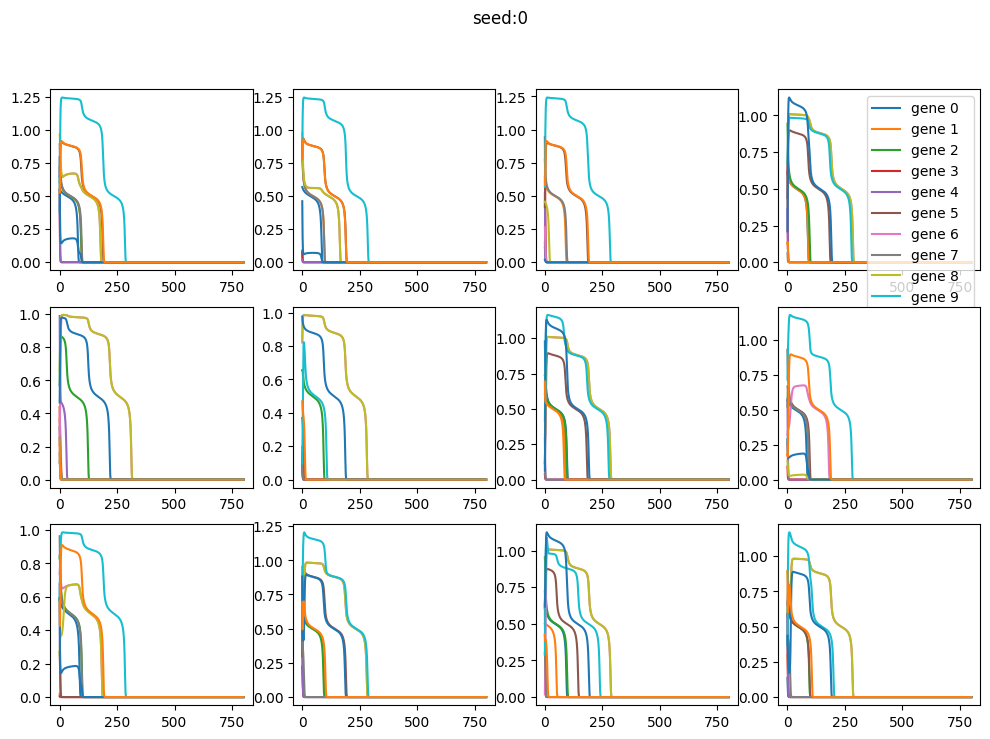

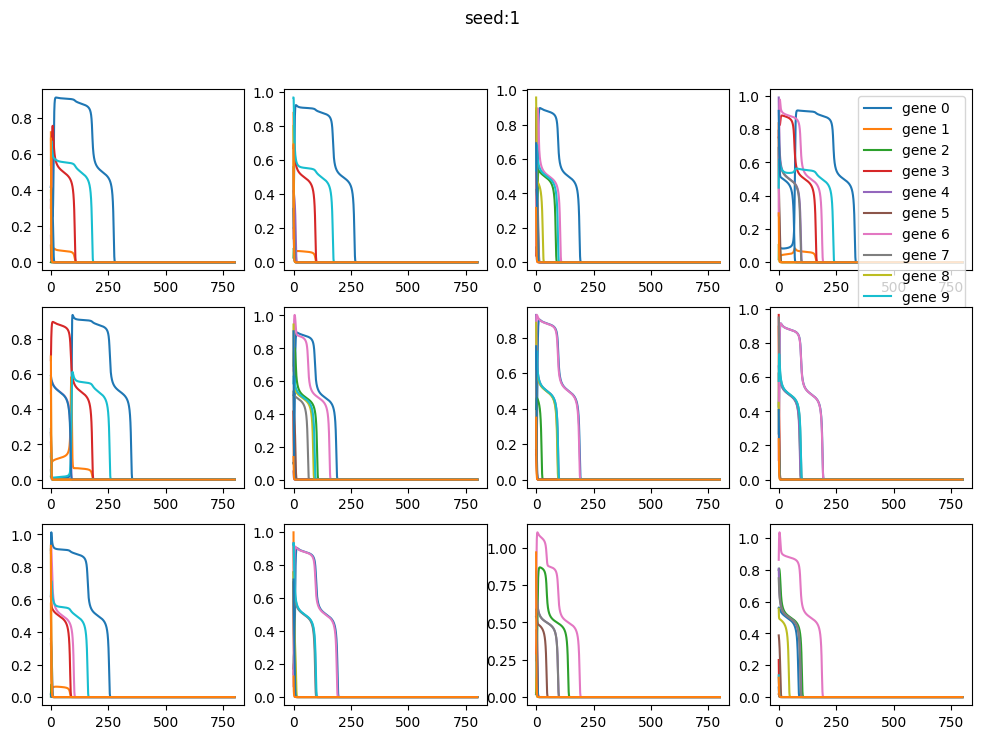

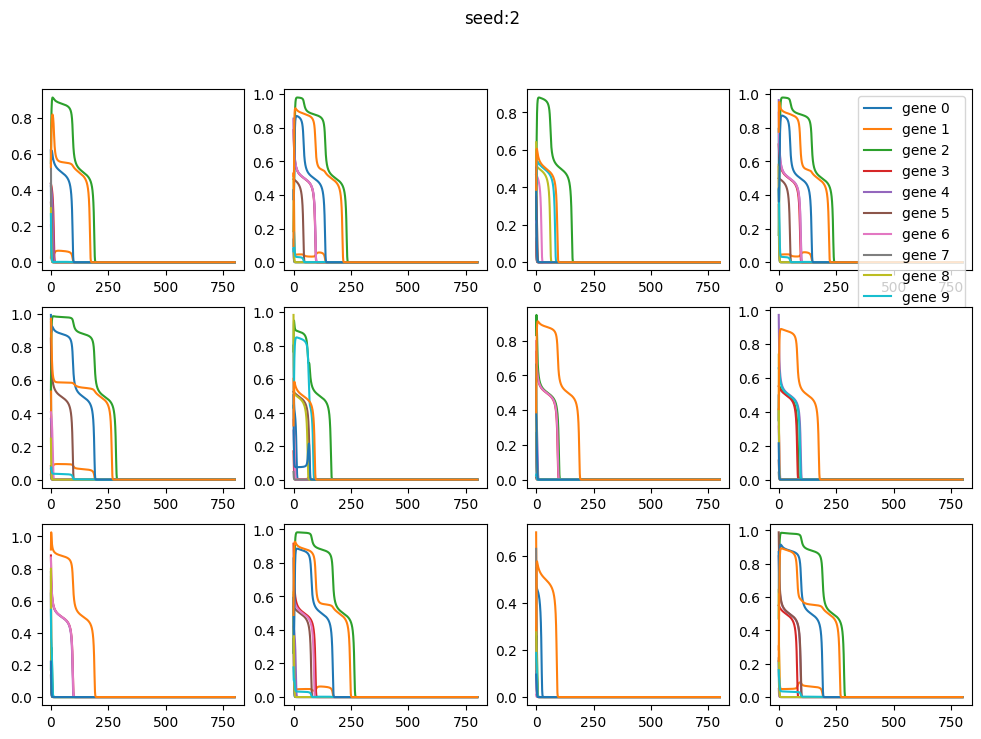

In [265]:
##################
import jax.numpy as jnp

def GRN_net(t, x, para):

    a, b, K, Ka, Ki, A = para

    N = len(x)
    xdot = np.zeros(N)

    for i in range(N):
        # Self activation
        self_act = a * x[i]**2 / (x[i]**2 + K**2)

        # Excitatory inputs
        exc_idx = np.where(A[i] == 1)[0]
        exc = np.sum(x[exc_idx]**2 / (x[exc_idx]**2 + Ka**2)) if exc_idx.size > 0 else 0.0
        exc *= b

        # Inhibitory inputs (multiplicative)
        inh_idx = np.where(A[i] == -1)[0]
        inh = np.prod(Ki**2 / (x[inh_idx]**2 + Ki**2)) if inh_idx.size > 0 else 1.0

        xdot[i] = (self_act + exc)*inh - x[i]

    return jnp.asarray(xdot)

# define network topology
n = 12
#  np.random.seed()
#     #     n = np.random.randint(6,15)
#     #     p_inhibitory = 0.4
#     # elif rndNet == 1:
#     #     rseed=5
#     #     np.random.seed(rseed)

seeds = np.random.randint(0,10000,10)
print(seeds)

# master_seed = 

for s in range(3):
    seed =  s   # deterministic but different per run

    rng = np.random.default_rng(seed)
    np.random.seed(seed)     # for legacy np.random.rand()

    G = nx.erdos_renyi_graph(n,0.15,directed=True,seed=seed)

    A = nx.to_numpy_array(G)

    p_inhibitory = 0.5

    # introduce inhibitory links
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            if A[i, j] == 1:
                if rng.random() < p_inhibitory:
                    A[i, j] = -1

    labels = [str(i) for i in range(n)]
    nodeColors = [(0.8, 0.8, 1, 1.0)] * n # all nodes have same color

    para = [0.998,0.25,0.5,0.5,0.5,A]
    dt = 0.2
    t_end=800
    timesteps = np.linspace(0,t_end,int(t_end/dt))

    plt.figure(figsize=(12,8))
    plt.suptitle(f"seed:{s}")
    for i in range(12):
        ic = np.random.uniform(0, 1, n)
        sol = solve_ivp(GRNnet, (0, t_end), ic,
                            t_eval=timesteps, args=(para,),method='RK45')

        plt.subplot(3,4,1+i)
        for ii in range(n):
            plt.plot(sol.t,sol.y[ii,:],label=f"gene {ii}")
        if i == 3: plt.legend()


# # Plot the network
# plt.figure(figsize=(6, 6))
# draw_network(A, nodeColors, labels,layout='neato',node_size=400,label_font_size=12)
# plt.title(f"Erdős–Rényi Graph (n={n}, p={1/np.sqrt(2*n):.3f})")
# plt.axis("off")
# plt.show()



In [ ]:

# define network topology
n = 12

for s in range(2):
    seed =  s   # deterministic but different per run

    rng = np.random.default_rng(seed)
    np.random.seed(seed)     # for legacy np.random.rand()

    G = nx.erdos_renyi_graph(n,0.15,directed=True,seed=seed)

    A = nx.to_numpy_array(G)

    p_inhibitory = 0.5

    # introduce inhibitory links
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            if A[i, j] == 1:
                if rng.random() < p_inhibitory:
                    A[i, j] = -1

    labels = [str(i) for i in range(n)]
    nodeColors = [(0.8, 0.8, 1, 1.0)] * n # all nodes have same color

    para = [0.998,0.25,0.5,0.5,0.5,A]
    dt = 0.2
    t_end=800
    timesteps = np.linspace(0,t_end,int(t_end/dt))

    fig = plt.figure(figsize=(12,8))
    plt.suptitle(f"seed:{s}")
    for i in range(12):
        ic = np.random.uniform(0, 1, n)
        sol = solve_ivp(mod.GRN_net, (0, t_end), ic,
                            t_eval=timesteps, args=(para,),method='RK45')

        plt.subplot(3,4,1+i)
        for ii in range(n):
            plt.plot(sol.t,sol.y[ii,:],label=f"gene {ii}")
        if i == 3: plt.legend()
    
    plt.savefig(f"seed_{s}.png",dpi=200)
    plt.close(fig)


# # Plot the network
# plt.figure(figsize=(6, 6))
# draw_network(A, nodeColors, labels,layout='neato',node_size=400,label_font_size=12)
# plt.title(f"Erdős–Rényi Graph (n={n}, p={1/np.sqrt(2*n):.3f})")
# plt.axis("off")
# plt.show()


[9222 4460 6619 4552 7619 3985 3978 4894 4217 8400]
